<a href="https://colab.research.google.com/github/jahnavitelsang/DATASCIENCE/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Decision tree

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/sales.csv')

In [3]:
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no


In [ ]:
#separate the numerial and categorical rows

In [9]:
x_cont = df.iloc[:,[1,2,3,4,5,7,8]]
x_cont.head()

#can also use df.iloc[:,np.r[1:6, 7:9]]

,CompPrice,Income,Advertising,Population,Price,Age,Education
0,138,73,11,276,120,42,17
1,111,48,16,260,83,65,10
2,113,35,10,269,80,59,12
3,117,100,4,466,97,55,14
4,141,64,3,340,128,38,13


In [12]:
y_cont = df.loc[:,['ShelveLoc','Urban','US','high']]
y_cont.head()

,ShelveLoc,Urban,US,high
0,Bad,Yes,Yes,yes
1,Good,Yes,Yes,yes
2,Medium,Yes,Yes,yes
3,Medium,Yes,Yes,no
4,Bad,Yes,No,no


In [15]:
from sklearn.preprocessing import StandardScaler

In [39]:
SS = StandardScaler()
x_cont_numerical = df.iloc[:,[1,2,3,4,5,7,8]]
SS_X = SS.fit_transform(x_cont_numerical)
SS_X = pd.DataFrame(SS_X, columns=x_cont_numerical.columns)
SS_X.head()
SS.X_cont = list(df.iloc[:,[1,2,3,4,5,7,8]])
SS_X.head()



,CompPrice,Income,Advertising,Population,Price,Age,Education
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872


In [ ]:
#now convert the categories into numbers

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
LE = LabelEncoder()

In [25]:
df['ShelveLoc'] = LE.fit_transform(df['ShelveLoc'])
df['Urban'] = LE.fit_transform(df['Urban'])
df['US'] = LE.fit_transform(df['US'])
df['high'] = LE.fit_transform(df['high'])
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,0,42,17,1,1,1
1,2,111,48,16,260,83,1,65,10,1,1,1
2,3,113,35,10,269,80,2,59,12,1,1,1
3,4,117,100,4,466,97,2,55,14,1,1,0
4,5,141,64,3,340,128,0,38,13,1,0,0


In [26]:
y_cont = df.loc[:,['ShelveLoc','Urban','US','high']]
y_cont.head()

,ShelveLoc,Urban,US,high
0,0,1,1,1
1,1,1,1,1
2,2,1,1,1
3,2,1,1,0
4,0,1,0,0


In [41]:
df_new = pd.concat([SS_X,y_cont], axis=1)
df_new.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc,Urban,US,high
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0,1,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,1,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,2,1,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,2,1,1,0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0,1,0,0


In [77]:
#data partision
Y = df_new['high']
X = df_new.drop(['high'], axis=1)
X


,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc,Urban,US
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,2,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,2,1,1
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0,1,0
...,...,...,...,...,...,...,...,...,...,...
395,0.850455,1.407551,1.560513,-0.420131,0.516132,-1.256023,0.038208,1,1,1
396,0.915749,-1.633482,-0.547271,-1.547909,0.177823,0.103677,-1.108033,2,0,1
397,2.417512,-1.526151,0.807733,0.700853,1.827078,-0.823391,1.566529,2,1,1
398,-1.630719,0.370022,0.054953,0.130170,-0.879391,-0.205346,-0.725953,0,1,1


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
DT = DecisionTreeClassifier()
DT.fit(X_train, Y_train)

DecisionTreeClassifier()

In [46]:
y_pred_train = y_pred = DT.predict(X_train)
y_pred_test = y_pred = DT.predict(X_test)


In [51]:
from sklearn.metrics import accuracy_score, log_loss

In [49]:
accuracy_score_train = accuracy_score(Y_train, y_pred_train)
accuracy_score_test = accuracy_score(Y_test, y_pred_test)
accuracy_score_train, accuracy_score_test

(1.0, 0.7333333333333333)

In [53]:
training_loss = log_loss(Y_train, y_pred_train)
test_loss = log_loss(Y_test, y_pred_test)
training_loss, test_loss

(2.2204460492503136e-16, 9.611640903764574)

In [54]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
model = DecisionTreeClassifier(criterion='gini')

In [64]:
#set up a shuffle split
from sklearn.model_selection import ShuffleSplit, cross_validate, cross_val_score

In [65]:
shuffle_split = ShuffleSplit(n_splits=10, test_size=0.3, random_state=100)

In [69]:
#apply cross val
cv_results = cross_validate(model, X, Y, cv=shuffle_split, scoring='accuracy',return_train_score=True)

#return_train_score=True: By default, cross-validation only looks at the test scores. Setting this to True tells Pandas to also save the model's accuracy on the training chunks so you can compare the two and check for overfitting.

In [70]:
train_results = cv_results['train_score']
test_results = cv_results['test_score']

In [72]:
np.round(train_results.mean(),2)

np.float64(1.0)

In [73]:
np.round(test_results.mean(),2)

np.float64(0.75)

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


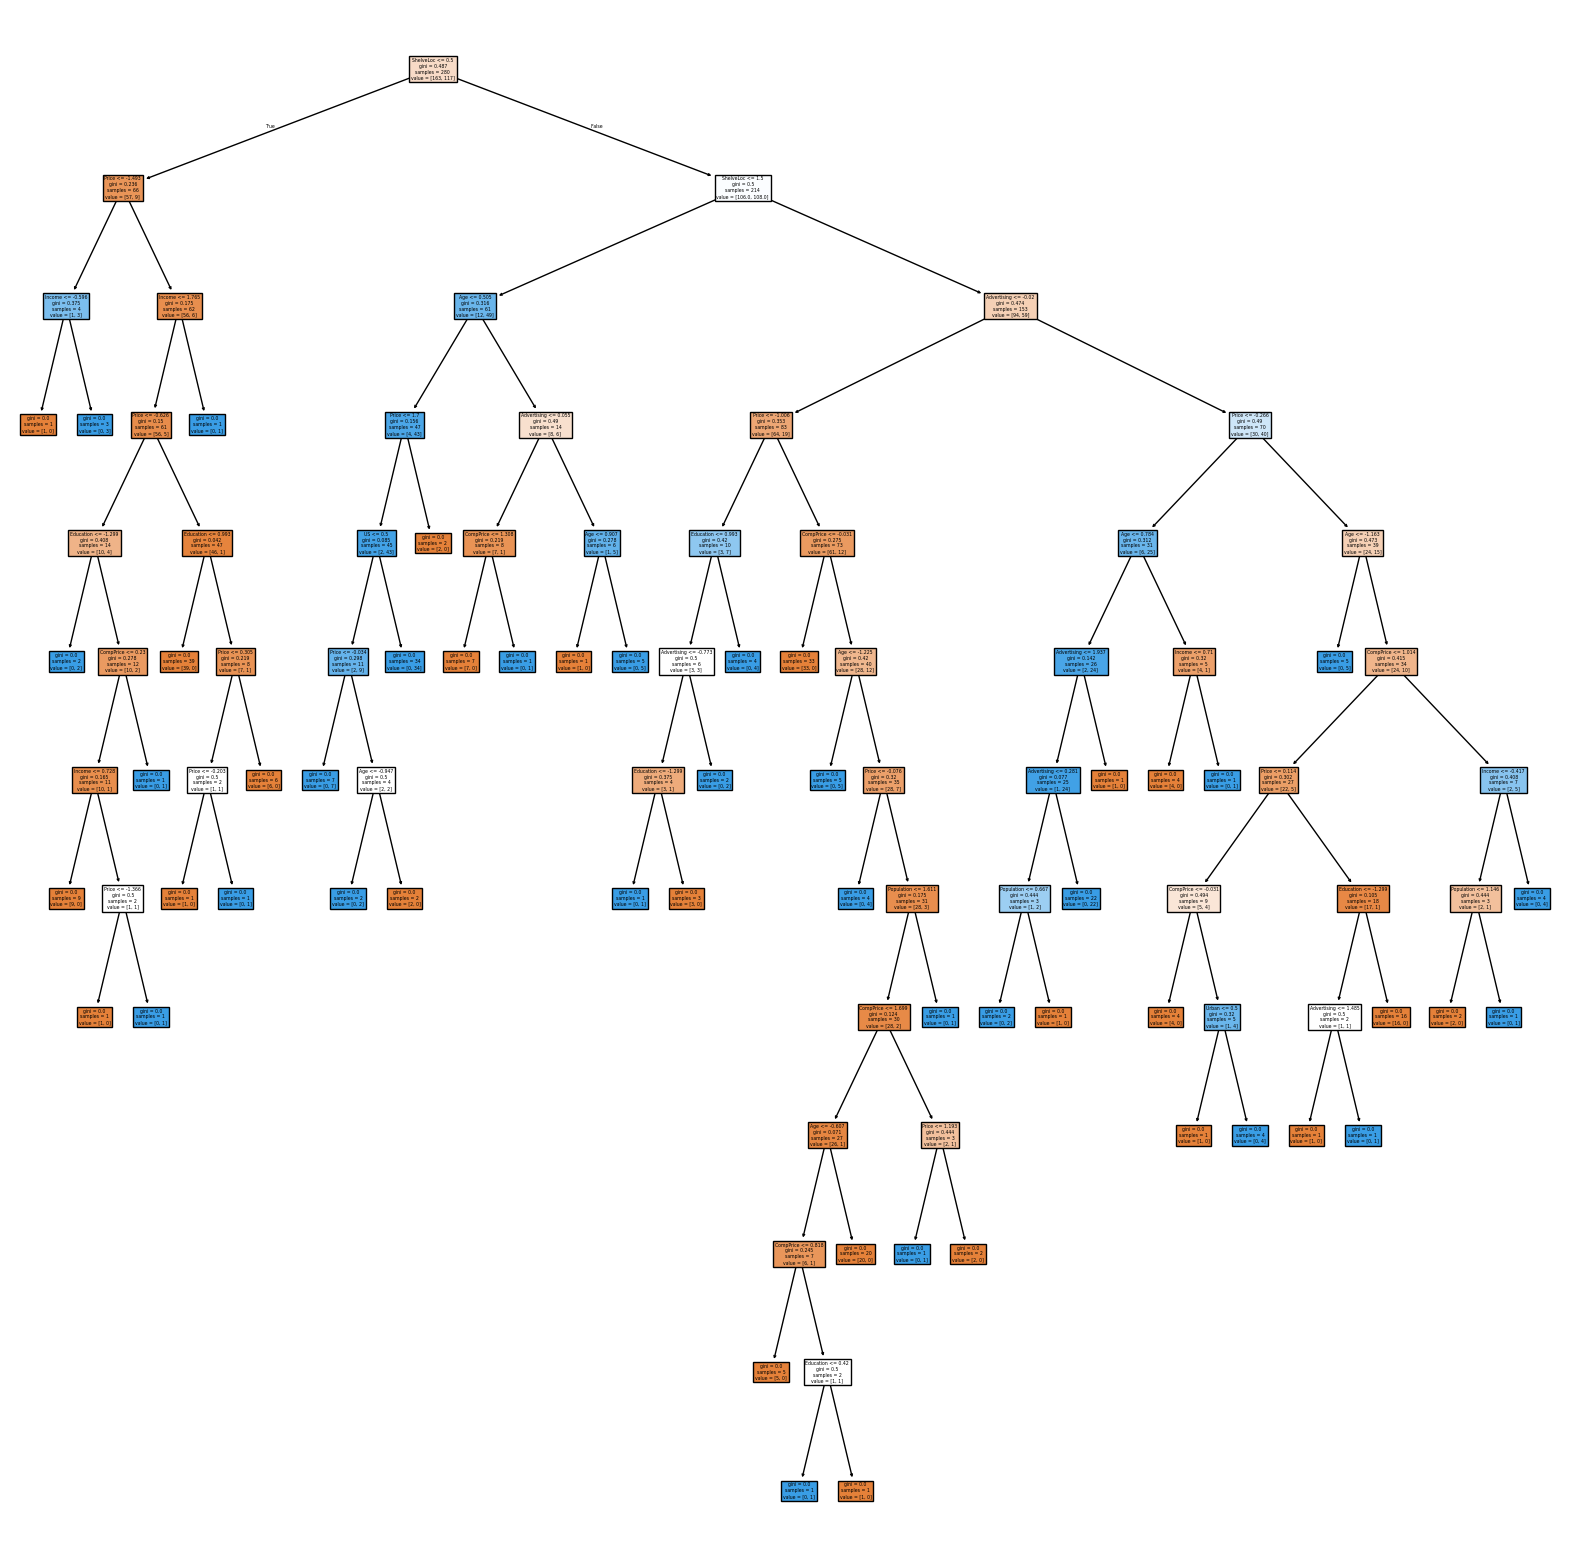

In [75]:
plt.figure(figsize = (20,20))
plot_tree(DT, filled=True, feature_names=X.columns)
plt.show()